In [5]:
import pandas as pd
import numpy as np

# Load the actual dataset
df = pd.read_excel("data/EastWestAirlines.xlsx", sheet_name="data")

# Display first 5 rows
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [6]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (3999, 12)

Columns:
['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll', 'Award?']

Missing Values:
ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64


In [7]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [8]:
# Check summary statistics
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


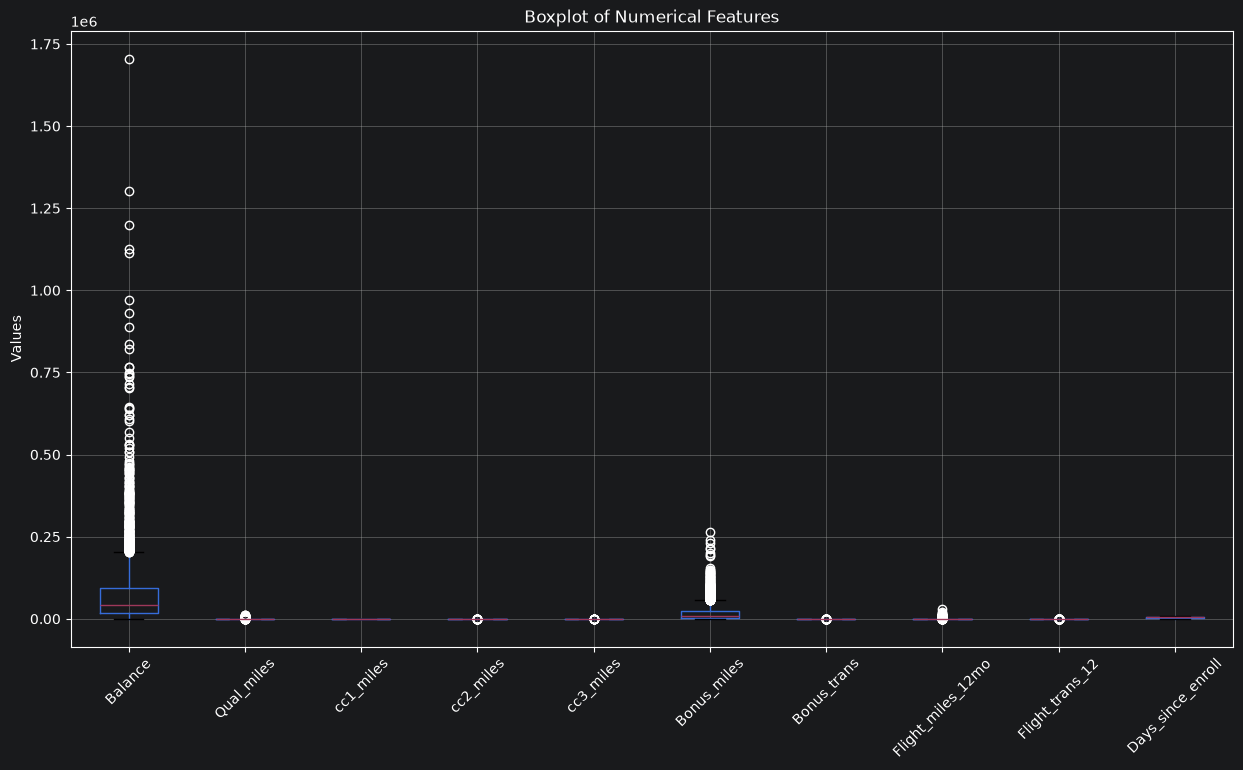

In [9]:
import matplotlib.pyplot as plt

# Select numerical features excluding ID and target
features = [
    'Balance',
    'Qual_miles',
    'cc1_miles',
    'cc2_miles',
    'cc3_miles',
    'Bonus_miles',
    'Bonus_trans',
    'Flight_miles_12mo',
    'Flight_trans_12',
    'Days_since_enroll'
]

# Create boxplots
plt.figure(figsize=(15, 8))
df[features].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features")
plt.ylabel("Values")
plt.show()

In [10]:
# Remove outliers using the IQR method

df_clean = df.copy()

for col in features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower_bound) &
        (df_clean[col] <= upper_bound)
    ]

print("Original dataset shape:", df.shape)
print("Shape after removing outliers:", df_clean.shape)
print("Rows removed:", df.shape[0] - df_clean.shape[0])

Original dataset shape: (3999, 12)
Shape after removing outliers: (2370, 12)
Rows removed: 1629


In [11]:
# Check the cleaned dataset
df_clean[features].describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
count,2370.000000,2370.0,2370.000000,2370.0,2370.0,2370.000000,2370.000000,2370.0,2370.0,2370.000000
mean,43142.116456,0.0,1.746414,1.0,1.0,9564.230802,8.751899,0.0,0.0,3891.261181
std,40690.784373,0.0,1.081834,0.0,0.0,12228.170566,7.402842,0.0,0.0,2062.465495
min,68.000000,0.0,1.000000,1.0,1.0,0.000000,0.000000,0.0,0.0,8.000000
25%,13874.250000,0.0,1.000000,1.0,1.0,375.000000,1.000000,0.0,0.0,2112.750000
50%,29189.000000,0.0,1.000000,1.0,1.0,3675.500000,9.000000,0.0,0.0,3775.500000
75%,60245.000000,0.0,3.000000,1.0,1.0,15154.500000,14.000000,0.0,0.0,5545.000000
max,202636.000000,0.0,5.000000,1.0,1.0,50752.000000,33.000000,0.0,0.0,8296.000000


In [13]:
from sklearn.preprocessing import StandardScaler

# Select features for clustering
X = df_clean[features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easy inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

# Display first 5 rows
X_scaled_df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
0,-0.368690,0.0,-0.690098,0.0,0.0,-0.768080,-1.047373,0.0,0.0,1.507611
1,-0.587434,0.0,-0.690098,0.0,0.0,-0.764726,-0.912261,0.0,0.0,1.492092
2,-0.043953,0.0,-0.690098,0.0,0.0,-0.445069,-0.642037,0.0,0.0,1.524099
3,-0.697261,0.0,-0.690098,0.0,0.0,-0.741415,-1.047373,0.0,0.0,1.484333
4,-0.656850,0.0,-0.690098,0.0,0.0,-0.782312,-1.182484,0.0,0.0,1.479483


In [14]:
print("Scaled data shape:", X_scaled_df.shape)

print("\nMean after scaling:")
print(X_scaled_df.mean().round(2))

print("\nStandard deviation after scaling:")
print(X_scaled_df.std().round(2))

Scaled data shape: (2370, 10)

Mean after scaling:
Balance             -0.0
Qual_miles           0.0
cc1_miles            0.0
cc2_miles            0.0
cc3_miles            0.0
Bonus_miles          0.0
Bonus_trans         -0.0
Flight_miles_12mo    0.0
Flight_trans_12      0.0
Days_since_enroll    0.0
dtype: float64

Standard deviation after scaling:
Balance              1.0
Qual_miles           0.0
cc1_miles            1.0
cc2_miles            0.0
cc3_miles            0.0
Bonus_miles          1.0
Bonus_trans          1.0
Flight_miles_12mo    0.0
Flight_trans_12      0.0
Days_since_enroll    1.0
dtype: float64


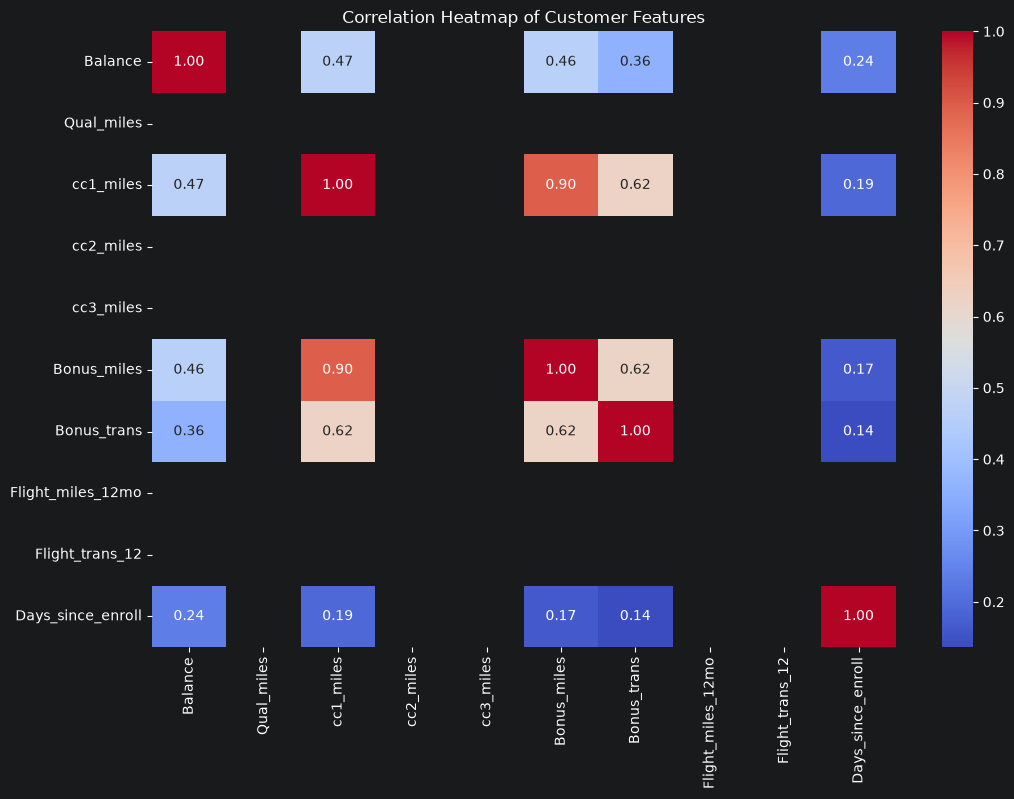

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlations
corr = df_clean[features].corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Customer Features")
plt.show()

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create PCA DataFrame
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

# Display explained variance
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance explained:",
      pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.56479096 0.19376352]

Total variance explained: 0.7585544876495751


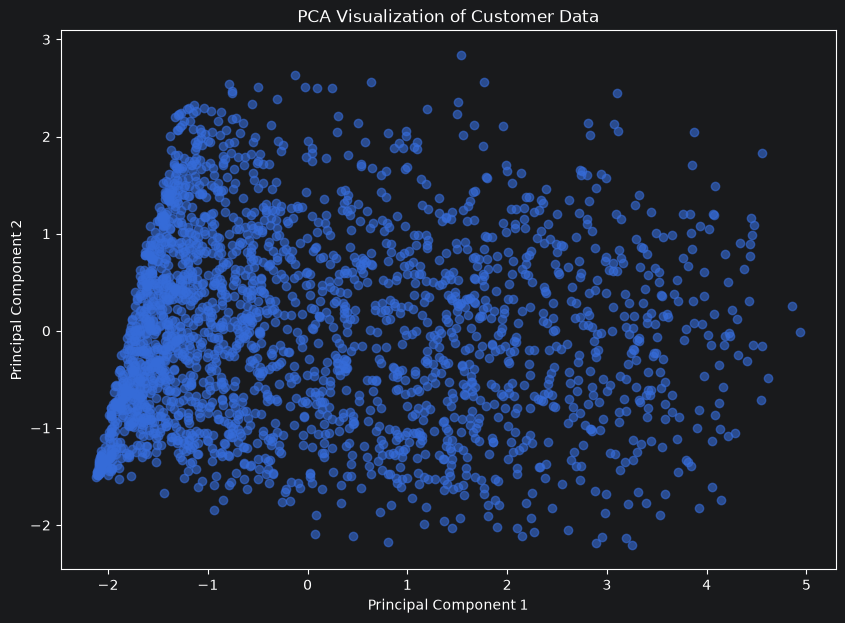

In [18]:
# Plot PCA projection
plt.figure(figsize=(10, 7))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Customer Data")
plt.show()

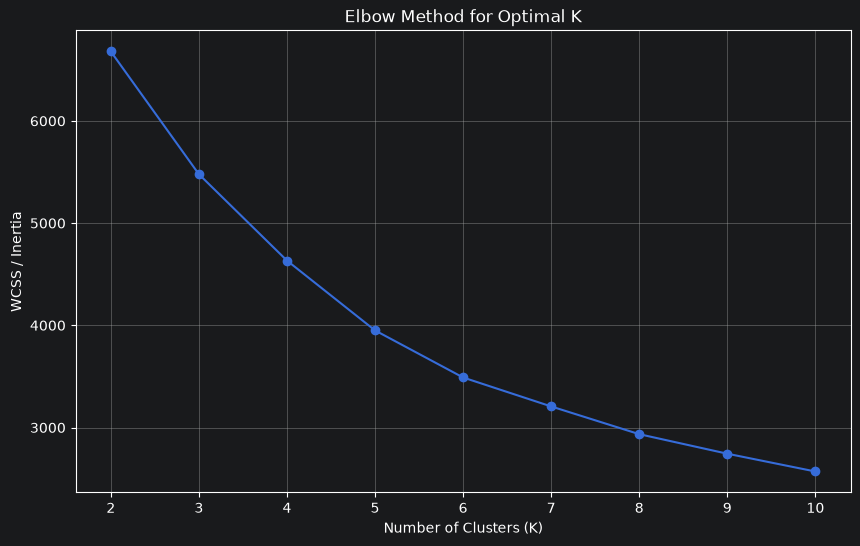

In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate WCSS for different numbers of clusters
wcss = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), wcss, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [20]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Display scores
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.4252
K = 3: Silhouette Score = 0.2980
K = 4: Silhouette Score = 0.2841
K = 5: Silhouette Score = 0.3034
K = 6: Silhouette Score = 0.3029
K = 7: Silhouette Score = 0.3043
K = 8: Silhouette Score = 0.3094
K = 9: Silhouette Score = 0.2989
K = 10: Silhouette Score = 0.2647


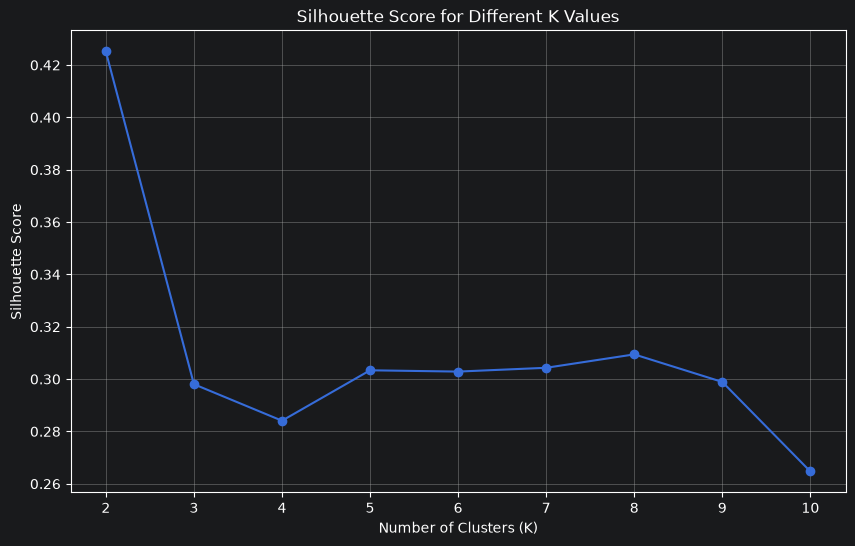

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [22]:
# Final K-Means model with K = 2

kmeans_final = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# Fit model and generate cluster labels
kmeans_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to the cleaned dataset
df_clean['KMeans_Cluster'] = kmeans_labels

# Cluster counts
print("K-Means clustering completed.")
print("\nCluster counts:")
print(df_clean['KMeans_Cluster'].value_counts().sort_index())

# Final silhouette score
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

print("\nFinal K-Means Silhouette Score:",
      round(kmeans_silhouette, 4))

K-Means clustering completed.

Cluster counts:
KMeans_Cluster
0     773
1    1597
Name: count, dtype: int64

Final K-Means Silhouette Score: 0.4252


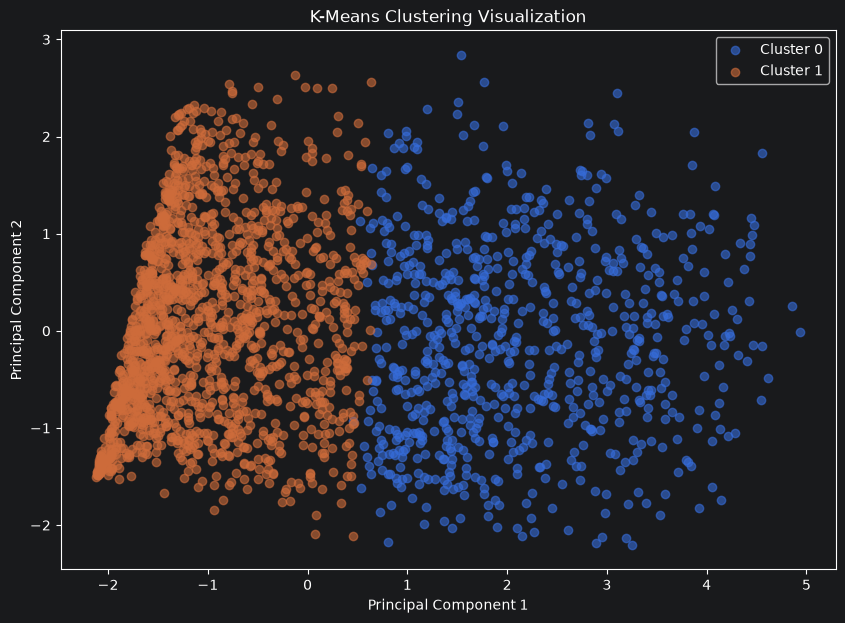

In [23]:
# Add cluster labels to PCA data
pca_df['KMeans_Cluster'] = kmeans_labels

# Plot K-Means clusters
plt.figure(figsize=(10, 7))

for cluster in sorted(pca_df['KMeans_Cluster'].unique()):
    cluster_data = pca_df[pca_df['KMeans_Cluster'] == cluster]

    plt.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        label=f'Cluster {cluster}',
        alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering Visualization")
plt.legend()
plt.show()

In [24]:
# Analyze cluster characteristics

cluster_summary = df_clean.groupby('KMeans_Cluster')[features].mean().round(2)

print("Cluster Characteristics:")
display(cluster_summary)

Cluster Characteristics:


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
KMeans_Cluster,,,,,,,,,,
0,74456.44,0.0,3.12,1.0,1.0,23541.01,15.71,0.0,0.0,4561.06
1,27984.96,0.0,1.08,1.0,1.0,2799.01,5.39,0.0,0.0,3567.06


In [25]:
# Compare cluster means

cluster_comparison = cluster_summary.T

print("Feature-wise comparison between clusters:")
display(cluster_comparison)

Feature-wise comparison between clusters:


KMeans_Cluster,0,1
Balance,74456.44,27984.96
Qual_miles,0.00,0.00
cc1_miles,3.12,1.08
cc2_miles,1.00,1.00
cc3_miles,1.00,1.00
Bonus_miles,23541.01,2799.01
Bonus_trans,15.71,5.39
Flight_miles_12mo,0.00,0.00
Flight_trans_12,0.00,0.00
Days_since_enroll,4561.06,3567.06


In [26]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Initial DBSCAN model
dbscan = DBSCAN(
    eps=0.8,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(X_scaled)

# Count clusters and noise points
unique_labels = set(dbscan_labels)

print("DBSCAN labels:", unique_labels)
print("\nCluster counts:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN labels: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(-1)}

Cluster counts:
-1     241
 0    1436
 1     158
 2     354
 3     181
Name: count, dtype: int64


In [27]:
# Calculate DBSCAN silhouette score
# Exclude noise points (-1) from the silhouette calculation

mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) > 1:
    dbscan_silhouette = silhouette_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )
    print("DBSCAN Silhouette Score:",
          round(dbscan_silhouette, 4))
else:
    print("Silhouette Score cannot be calculated.")

DBSCAN Silhouette Score: 0.2152


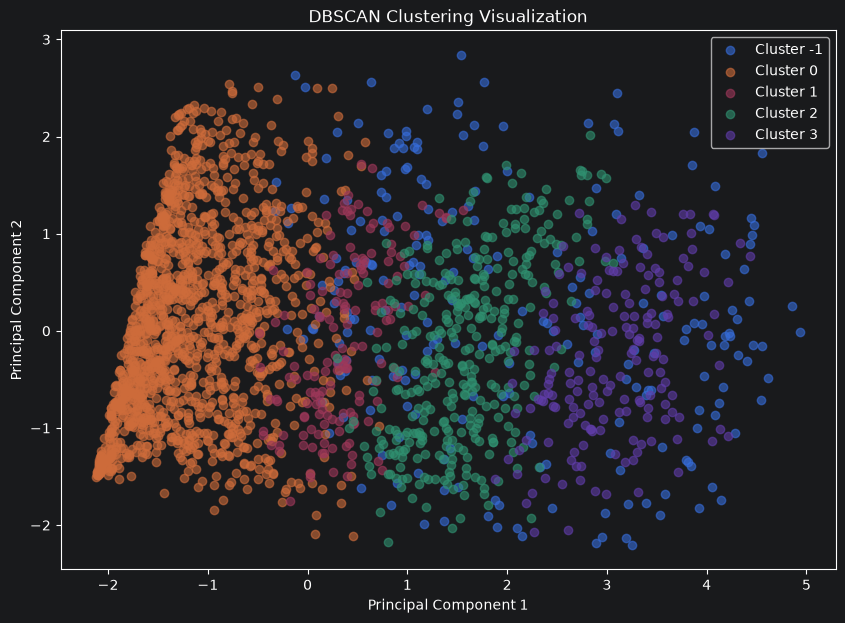

In [28]:
# Add DBSCAN labels to PCA data
pca_df['DBSCAN_Cluster'] = dbscan_labels

# Plot DBSCAN clusters
plt.figure(figsize=(10, 7))

for cluster in sorted(pca_df['DBSCAN_Cluster'].unique()):
    cluster_data = pca_df[pca_df['DBSCAN_Cluster'] == cluster]

    plt.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        label=f'Cluster {cluster}',
        alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clustering Visualization")
plt.legend()
plt.show()

In [29]:
# Final comparison of clustering algorithms

comparison = pd.DataFrame({
    'Algorithm': ['K-Means', 'DBSCAN'],
    'Number_of_Clusters': [2, len(set(dbscan_labels)) - 1],
    'Noise_Points': [0, (dbscan_labels == -1).sum()],
    'Silhouette_Score': [
        kmeans_silhouette,
        dbscan_silhouette
    ]
})

comparison['Silhouette_Score'] = comparison['Silhouette_Score'].round(4)

display(comparison)

,Algorithm,Number_of_Clusters,Noise_Points,Silhouette_Score
0,K-Means,2,0,0.4252
1,DBSCAN,4,241,0.2152


In [30]:
# Save clustering results

df_clean.to_csv(
    "data/EastWestAirlines_clustering_results.csv",
    index=False
)

print("Clustering results saved successfully.")

Clustering results saved successfully.


In [31]:
# Add DBSCAN cluster labels to the cleaned dataset
df_clean['DBSCAN_Cluster'] = dbscan_labels

# Save the complete clustering results
df_clean.to_csv(
    "data/EastWestAirlines_clustering_results.csv",
    index=False
)

print("Final clustering results saved successfully.")
print("\nColumns saved:")
print(df_clean.columns.tolist())

Final clustering results saved successfully.

Columns saved:
['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll', 'Award?', 'KMeans_Cluster', 'DBSCAN_Cluster']


Final conclusion

K-Means performed better than DBSCAN for this dataset based on the Silhouette Score. K-Means produced two relatively distinct customer segments with a score of 0.4252, while DBSCAN produced four clusters and 241 noise observations with a lower score of 0.2152.

The K-Means analysis indicates that Cluster 0 consists of fewer but higher-value and more engaged customers, with higher balances, bonus miles, bonus transactions, and longer enrollment duration. Cluster 1 represents the larger group of customers with comparatively lower values across these characteristics.

You have now completed the main requirements in the assignment document: preprocessing, EDA, visualization, K-Means, Elbow Method, DBSCAN, cluster interpretation, cluster visualization, and silhouette-based evaluation.